# Projected Gradient Descent (MATH 677)

This notebook is built around **my own** MATH 677 solver,
`course-files/02-linear-algebra/proj_gradient.py`. It minimizes a function subject to a
constraint using **projected gradient descent** with an **Armijo backtracking line search** —
no optimization library, just `numpy` for the linear algebra and `sympy` to get the gradient
symbolically.

The recipe each iteration:

1. Take an unconstrained gradient step `x - ∇f(x)`.
2. If that leaves the feasible set, **project** it back onto the boundary (rescale onto the
   circle, or drop perpendicularly onto the half-plane).
3. Backtrack the step length `α` (shrink by `ρ`) until the **Armijo** sufficient-decrease
   condition holds, then move.

I run it on two convex constraint sets — a **disk** and a **half-plane** — and check every
answer against the closed-form minimizer. See the
[Gradient Descent](../gradient-descent.md) page for the geometry and the by-hand worked
example.

In [1]:
import numpy as np
from sympy import symbols, lambdify, diff
import matplotlib.pyplot as plt

# dataviz palette
BLUE, GREEN, ORANGE, RED, GRID, MUTED = "#2a78d6", "#008300", "#eb6834", "#e34948", "#e1e0d9", "#898781"
plt.rcParams.update({"figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
                     "font.size": 11, "axes.grid": True, "grid.color": GRID,
                     "grid.linewidth": 0.8, "axes.axisbelow": True})
np.random.seed(0)

## The solver

These two functions are my `proj_gradient.py`, lightly instrumented to also **record the path**
(`history`) so I can plot convergence. The math — the projection step and the Armijo inner loop
— is unchanged.

In [2]:
def proj_gradient_circle(f, gradf, x0, r, tol, rho, c1):
    """Minimize f over the disk x^2 + y^2 <= r^2 by projected gradient descent."""
    x = x0.copy()
    history = [x.copy()]
    while True:
        grad = gradf(x)
        x_test = x - grad
        norm_test = np.sqrt(np.dot(x_test, x_test))
        if norm_test > r:                       # left the disk -> project onto boundary
            x_test = (r / norm_test) * x_test
        if np.linalg.norm(x - x_test) < tol:
            break
        d = x_test - x
        alpha = 1.0
        while f(x + alpha * d) > f(x) + c1 * alpha * np.dot(grad, d):   # Armijo backtracking
            alpha = rho * alpha
        x = x + alpha * d
        history.append(x.copy())
    return x, np.array(history)


def proj_gradient_plane(f, gradf, x0, n, c, tol, rho, c1):
    """Minimize f over the half-plane n . x <= c by projected gradient descent."""
    x = x0.copy()
    history = [x.copy()]
    while True:
        grad = gradf(x)
        x_test = x - grad
        constraint_val = np.dot(n, x_test)
        if constraint_val > c:                  # outside -> drop perpendicularly onto the plane
            x_test = x_test - ((constraint_val - c) / np.dot(n, n)) * n
        diff = x - x_test
        if np.sqrt(np.dot(diff, diff)) < tol:
            break
        d = x_test - x
        alpha = 1.0
        while f(x + alpha * d) > f(x) + c1 * alpha * np.dot(grad, d):
            alpha = rho * alpha
        x = x + alpha * d
        history.append(x.copy())
    return x, np.array(history)

## Building the objective with sympy

I write the objective symbolically and let sympy hand me the gradient — no hand-derived
derivatives, no chance of a sign slip. Here `f(x, y) = 0.3(x−2)² + 0.3(y−3)²`, a bowl centered
at `(2, 3)`.

In [3]:
x, y = symbols('x y')
f_exp = 0.3*(x-2)**2 + 0.3*(y-3)**2
f_lambda = lambdify((x, y), f_exp)
f = lambda v: f_lambda(v[0], v[1])
gradf_exp = [diff(f_exp, i) for i in (x, y)]
gradf_list = lambdify((x, y), gradf_exp, "numpy")
gradf = lambda v: np.array(gradf_list(v[0], v[1]))

tol, rho, c1 = 1e-5, 0.5, 0.1
print("objective:", f_exp)
print("gradient :", gradf_exp)

objective: 0.3*(x - 2)**2 + 0.3*(y - 3)**2
gradient : [0.6*x - 1.2, 0.6*y - 1.8]


## Case 1 — a binding disk constraint

With radius `r = 2`, the unconstrained minimum `(2, 3)` sits **outside** the disk (its norm is
`√13 ≈ 3.6`). So the constrained optimum is on the boundary, in the direction of `(2, 3)`:
`x* = r · (2,3)/‖(2,3)‖`. Projected GD should walk to that boundary point.

In [4]:
r = 2.0
x0 = np.array([0.9, -0.6])
x_star, hist = proj_gradient_circle(f, gradf, x0, r, tol, rho, c1)
exact = r * np.array([2, 3]) / np.linalg.norm([2, 3])
print(f"projected GD : {x_star}")
print(f"closed form  : {exact}")
print(f"max abs error: {np.max(np.abs(x_star - exact)):.2e}")

projected GD : [1.10940964 1.66409442]
closed form  : [1.10940039 1.66410059]
max abs error: 9.25e-06


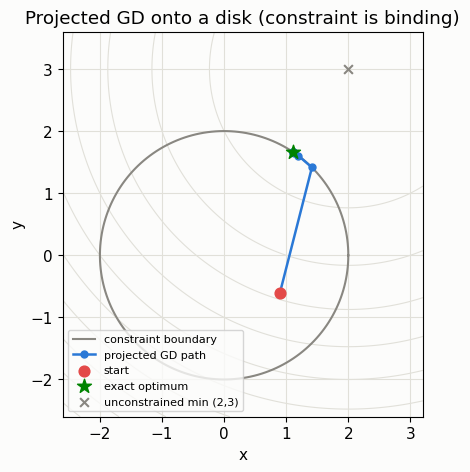

In [5]:
# contour of f, the disk constraint, and the descent path
gx = np.linspace(-2.6, 3.2, 240); gy = np.linspace(-2.6, 3.6, 240)
GX, GY = np.meshgrid(gx, gy)
Z = 0.3*(GX-2)**2 + 0.3*(GY-3)**2
fig, ax = plt.subplots(figsize=(6, 5))
ax.contour(GX, GY, Z, levels=12, colors=GRID, linewidths=0.8)
th = np.linspace(0, 2*np.pi, 200)
ax.plot(r*np.cos(th), r*np.sin(th), color=MUTED, lw=1.5, label="constraint boundary")
ax.plot(hist[:, 0], hist[:, 1], "-o", color=BLUE, ms=5, lw=1.8, label="projected GD path")
ax.scatter(*hist[0], color=RED, s=60, zorder=5, label="start")
ax.scatter(*exact, color=GREEN, s=110, marker="*", zorder=5, label="exact optimum")
ax.scatter([2], [3], color=MUTED, s=40, marker="x", label="unconstrained min (2,3)")
ax.set_aspect("equal"); ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Projected GD onto a disk (constraint is binding)")
ax.legend(loc="lower left", fontsize=8); plt.show()

The path steps toward `(2, 3)`, hits the circle, and slides along the boundary to the
optimum — where the negative gradient points straight out of the disk and the projection can't
make further progress. Error vs the closed form is at the tolerance floor.

## Case 2 — a slack disk constraint

Now `r = 5`. The unconstrained minimum `(2, 3)` is **inside** the disk (`√13 < 5`), so the
constraint never binds and projected GD should recover the unconstrained optimum exactly.

In [6]:
r = 5.0
x0 = np.array([0.2, 0.1])
x_star, hist2 = proj_gradient_circle(f, gradf, x0, r, tol, rho, c1)
print(f"projected GD : {x_star}")
print(f"closed form  : {np.array([2., 3.])}   (constraint inactive)")
print(f"iterations   : {len(hist2)}")

projected GD : [1.99999517 2.99999222]
closed form  : [2. 3.]   (constraint inactive)
iterations   : 15


## Case 3 — a half-plane constraint in 3-D

Same idea, different projection. Minimize `0.3[(x−2)² + (y−3)² + (z−1)²]` subject to
`4x − 3y + 2z ≤ 5`. The unconstrained min `(2, 3, 1)` satisfies `4·2 − 3·3 + 2·1 = 1 ≤ 5`, so
the constraint is slack and we should land on `(2, 3, 1)`.

In [7]:
x, y, z = symbols('x y z')
f3_exp = 0.3*(x-2)**2 + 0.3*(y-3)**2 + 0.3*(z-1)**2
f3_l = lambdify((x, y, z), f3_exp)
f3 = lambda v: f3_l(v[0], v[1], v[2])
g3_exp = [diff(f3_exp, i) for i in (x, y, z)]
g3_l = lambdify((x, y, z), g3_exp, "numpy")
gradf3 = lambda v: np.array(g3_l(v[0], v[1], v[2]))

n = np.array([4., -3., 2.]); c = 5.0
x0 = np.array([0.3, 0.2, 0.1])
x_star3, _ = proj_gradient_plane(f3, gradf3, x0, n, c, tol, rho, c1)
print(f"projected GD : {x_star3}")
print(f"closed form  : {np.array([2., 3., 1.])}")
print(f"constraint 4x-3y+2z = {n @ x_star3:.3f}  (<= {c})")

projected GD : [1.99999544 2.99999248 0.99999758]
closed form  : [2. 3. 1.]
constraint 4x-3y+2z = 1.000  (<= 5.0)


## Convergence

Objective value versus iteration for the binding-disk case (Case 1). The Armijo line search
gives smooth, monotone decrease down to the constrained optimum.

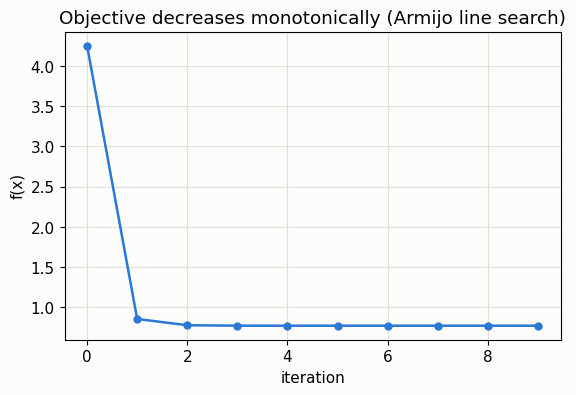

In [8]:
fvals = [f(p) for p in hist]
fig, ax = plt.subplots(figsize=(6.4, 4))
ax.plot(fvals, "-o", color=BLUE, ms=5, lw=1.8)
ax.set_xlabel("iteration"); ax.set_ylabel("f(x)")
ax.set_title("Objective decreases monotonically (Armijo line search)")
plt.show()

## Takeaways

- **Projection is the only new idea.** Take the ordinary gradient step, then snap back onto the
  feasible set — a rescale for the disk, a perpendicular drop for the half-plane. Both are
  closed-form because the sets are [convex](../convex-optimization.md).
- **Armijo removes the step-size guesswork.** Backtracking `α` until sufficient decrease holds
  keeps every step productive without hand-tuning a learning rate.
- **Verified against closed form.** Binding constraint → boundary point; slack constraint →
  unconstrained min. Both match the exact answer to tolerance, which is how I know the
  implementation is right.
- **Same skeleton as ML training.** Swap the sympy gradient for backprop and the fixed rule for
  Adam and this *is* a constrained training loop.